# Conteo Automático de Células en Imágenes AOSLO mediante Segmentación con Vision Transformers
## Proyecto Final - Visión por Computadora

### Juan Andrés Martínez - Universidad de la Sabana

## 1. Introducción

El conteo de células en imágenes AOSLO constituye una tarea fundamental para el análisis de estructuras retinianas. Sin embargo, el proceso manual resulta costoso y presenta variabilidad entre observadores.

En este proyecto se propone un enfoque basado en segmentación semántica utilizando un Vision Transformer (ViT) ligero para identificar regiones celulares y posteriormente estimar el número de células presentes en cada imagen.

## 2. Descripción del Problema

Dada una imagen AOSLO, el objetivo es identificar automáticamente las regiones correspondientes a células mediante segmentación semántica binaria.

Posteriormente, las máscaras segmentadas son utilizadas para estimar el número total de células presentes en la imagen.


## 3. Carga de Librerías y Fijado de Semilla 

In [37]:
!pip install imageio scikit-image opencv-python -q pandas
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import imageio.v2 as imageio
from PIL import Image
import cv2
from skimage.feature import peak_local_max
from skimage.measure import label, regionprops
from skimage.segmentation import watershed
from scipy import ndimage
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import warnings
warnings.filterwarnings('ignore')

#Semillas globales para reproducibilidad
global_seed = 42

def set_global_seeds(seed=global_seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_global_seeds()

print('TensorFlow version:', tf.__version__)
print(f'Semilla global fijada: {global_seed}')

TensorFlow version: 2.21.0
Semilla global fijada: 42


## 4. Construcción de Máscaras Binarias

El dataset original proporciona mapas de densidad en lugar de coordenadas explícitas. Para el enfoque de segmentación, extraeremos las coordenadas de los centroides buscando los máximos locales en los mapas de densidad. Luego, dibujaremos pequeñas circunferencias centradas en estas coordenadas para crear las **máscaras binarias** (ground truth).

In [38]:
#Es necesario cambiar la variable base path dependiendo de donde se corra el notebook
base_path = "/Users/juanchimartinez/Downloads/Parcial CV 2/AOSLO-Cell-Density-Estimation/data"

def extract_centroids_and_create_mask(density_map, img_shape=(224, 224), radius=2):
    # Encontrar picos locales (centroides) en el mapa de densidad
    # El mapa de densidad tiene valores altos donde hay células
    coordinates = peak_local_max(density_map, min_distance=2, threshold_abs=0.01)
    
    # Crear una máscara en blanco
    mask = np.zeros(img_shape, dtype=np.float32)
    
    # Dibujar circunferencias en cada centroide
    for y, x in coordinates:
        # Usar cv2.circle requiere coordenadas enteras (x, y)
        # Aquí es donde dibujamos círculos alrededor de las células\n
        cv2.circle(mask, (int(x), int(y)), radius, 1.0, -1)
        # Aquí es donde dibujamos círculos alrededor de las células\n
        
    return mask, len(coordinates)

def load_segmentation_data(folder_name):
    full_path = os.path.join(base_path, folder_name)
    images, masks, counts = [], [], []

    if not os.path.exists(full_path):
        print(f"Carpeta no encontrada: {full_path}")
        return np.array([]), np.array([]), np.array([])

    all_files = os.listdir(full_path)
    density_files = [f for f in all_files if 'Density' in f and f.endswith('.tif')]

    print(f"\n--- Cargando datos de {folder_name} ---")
    
    for d_file in density_files:
        possible_names = [
            d_file.replace('_Density.tif', '.tif'),
            d_file.replace('Density', '').replace('..', '.'),
            d_file.replace('_Density', '')
        ]
        img_file = next((n for n in possible_names if n in all_files and n != d_file), None)

        if img_file:
            try:
                # Cargar imagen original
                img = Image.open(os.path.join(full_path, img_file)).convert("RGB")
                img = img.resize((224, 224))
                img_array = np.array(img).astype(np.float32) / 255.0

                # Cargar densidad original y redimensionar para que coincida
                dens = imageio.imread(os.path.join(full_path, d_file)).astype(np.float32)
                dens_resized = cv2.resize(dens, (224, 224), interpolation=cv2.INTER_LINEAR)
                
                # Crear máscara binaria con las coordenadas
                mask, count = extract_centroids_and_create_mask(dens_resized, img_shape=(224, 224), radius=4)

                if count > 0:
                    images.append(img_array)
                    masks.append(mask[..., np.newaxis]) # Añadir canal extra (224, 224, 1)
                    counts.append(count)
                    
            except Exception as e:
                pass

    return np.array(images), np.array(masks), np.array(counts)

print("Procesando imágenes y generando máscaras...")
X_train, y_train_masks, train_counts = load_segmentation_data("Training+Density")
X_val, y_val_masks, val_counts = load_segmentation_data("Validation+Density")

print(f"\nShapes Train: {X_train.shape}, Máscaras: {y_train_masks.shape}")
print(f"Shapes Val: {X_val.shape}, Máscaras: {y_val_masks.shape}")

# ==========================================
# CÁLCULO DE LA DISTRIBUCIÓN DE CLASES (0 vs 1)
# ==========================================
total_pixels = y_train_masks.size
total_1s = np.sum(y_train_masks)
total_0s = total_pixels - total_1s

print(f"\n--- Distribución de píxeles en Entrenamiento ---")
print(f"Total píxeles de fondo (0): {total_0s:,.0f} ({total_0s/total_pixels*100:.2f}%)")
print(f"Total píxeles de célula (1): {total_1s:,.0f} ({total_1s/total_pixels*100:.2f}%)")

# Calcular pesos para balancear la pérdida
pos_weight = total_0s / (total_1s + 1e-5)
print(f"\nPeso sugerido para la clase positiva (células): {pos_weight:.2f}")


Procesando imágenes y generando máscaras...

--- Cargando datos de Training+Density ---

--- Cargando datos de Validation+Density ---

Shapes Train: (184, 224, 224, 3), Máscaras: (184, 224, 224, 1)
Shapes Val: (80, 224, 224, 3), Máscaras: (80, 224, 224, 1)

--- Distribución de píxeles en Entrenamiento ---
Total píxeles de fondo (0): 8,118,788 (87.94%)
Total píxeles de célula (1): 1,113,596 (12.06%)

Peso sugerido para la clase positiva (células): 7.29


## 5. Visualizaciones de Ejemplo
Comprobemos que las máscaras generadas corresponden correctamente a las células en la imagen original.

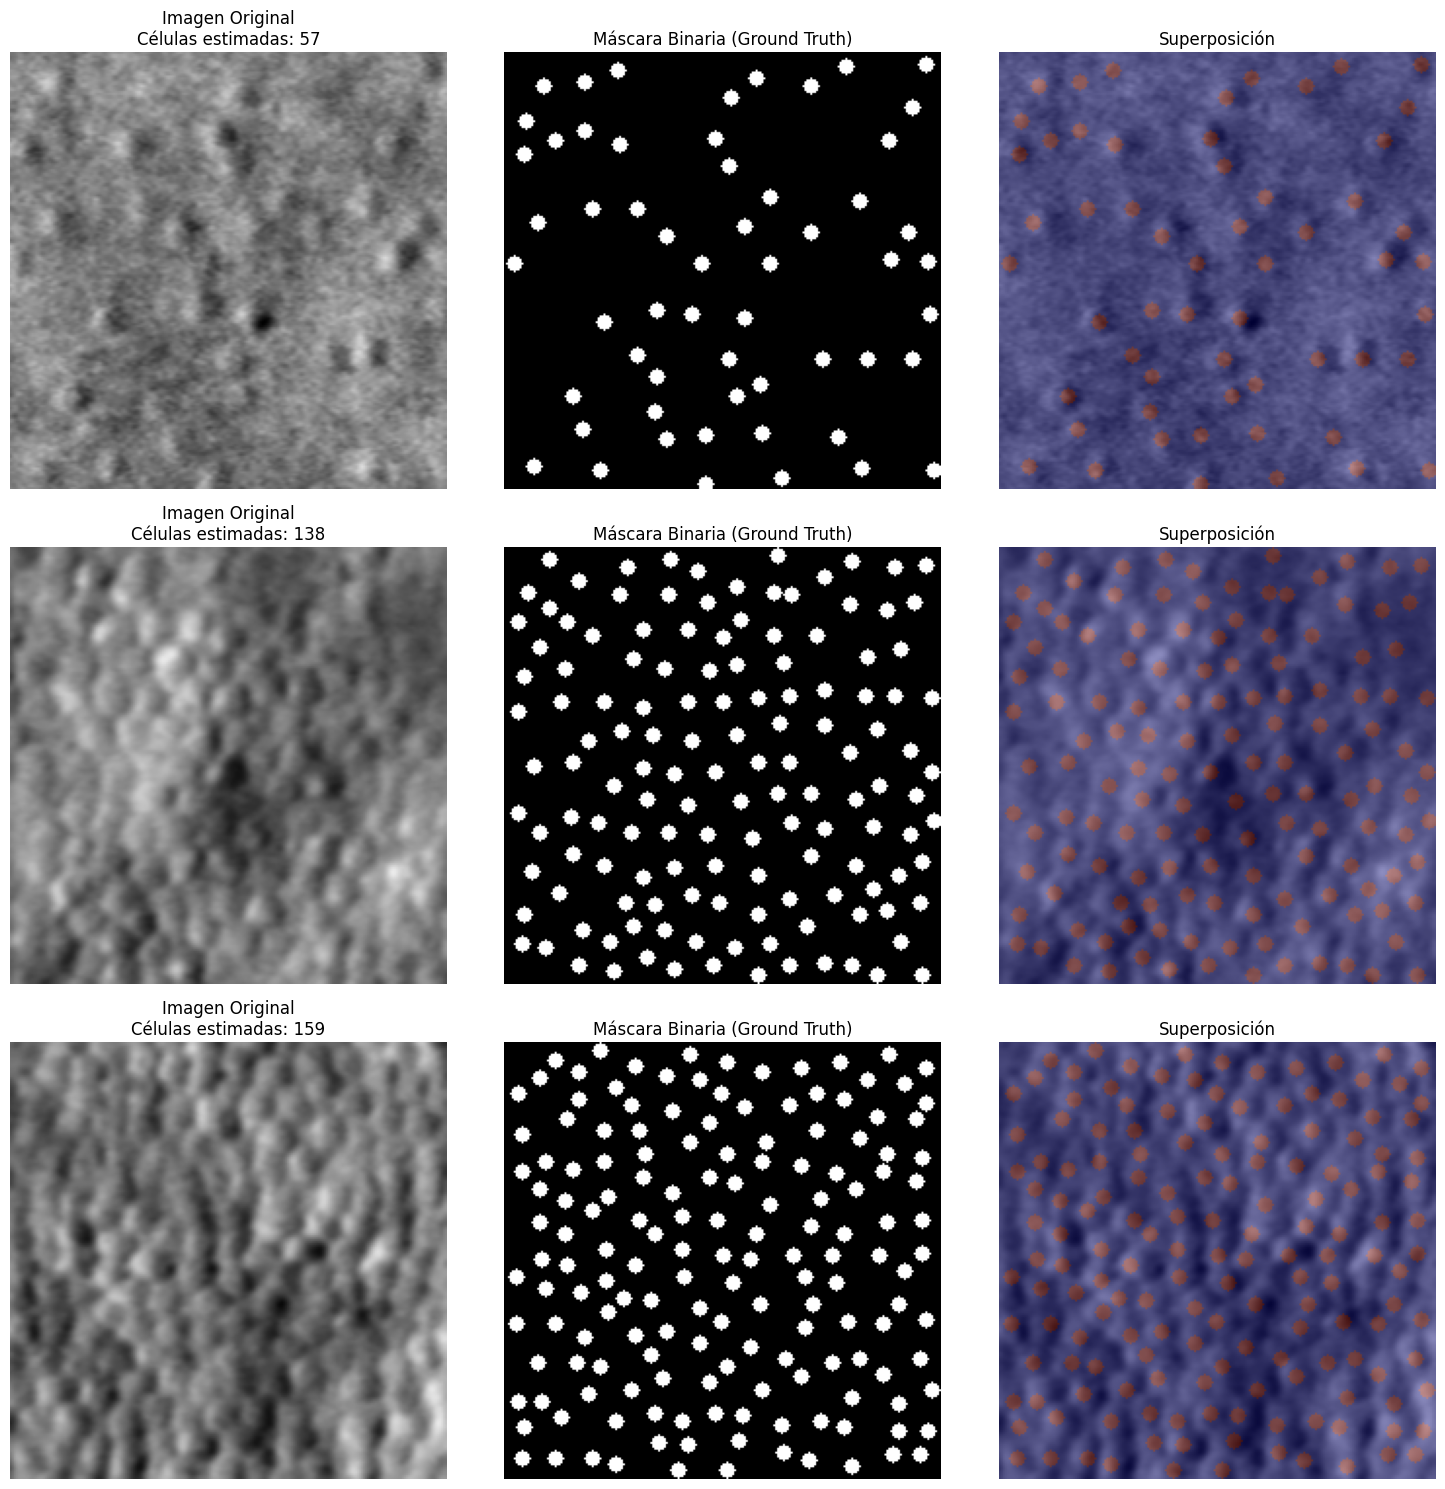

In [39]:
def plot_samples(X, y_masks, counts, num_samples=3):
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    
    for i in range(num_samples):
        idx = np.random.randint(0, len(X))
        
        # Imagen Original
        axes[i, 0].imshow(X[idx])
        axes[i, 0].set_title(f"Imagen Original\nCélulas estimadas: {counts[idx]}")
        axes[i, 0].axis('off')
        
        # Máscara Binaria
        axes[i, 1].imshow(y_masks[idx].squeeze(), cmap='gray')
        axes[i, 1].set_title("Máscara Binaria (Ground Truth)")
        axes[i, 1].axis('off')
        
        # Overlay superpuesto
        axes[i, 2].imshow(X[idx])
        axes[i, 2].imshow(y_masks[idx].squeeze(), cmap='jet', alpha=0.4)
        axes[i, 2].set_title("Superposición")
        axes[i, 2].axis('off')
        
    plt.tight_layout()
    plt.show()

plot_samples(X_train, y_train_masks, train_counts)

## 6. Diseñar Dataset para Segmentación (tf.data)

In [40]:
BATCH_SIZE = 8
AUTOTUNE = tf.data.AUTOTUNE

def augment_segmentation(image, mask):
    # Aumentation coherente para imagen y máscara
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)
        
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)
        
    # Variaciones de color solo a la imagen
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    image = tf.clip_by_value(image, 0.0, 1.0)
    
    return image, mask

def make_seg_dataset(X, y, aug_fn=None, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=42)
    if aug_fn:
        ds = ds.map(aug_fn, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_seg_dataset(X_train, y_train_masks, aug_fn=augment_segmentation, shuffle=True)
val_ds = make_seg_dataset(X_val, y_val_masks, aug_fn=None, shuffle=False)

print(f"Train batches: {len(train_ds)}, Val batches: {len(val_ds)}")

Train batches: 23, Val batches: 10


## 7. Implementación del Modelo de Segmentación (Vision Transformer - ViT)

Selección del Modelo

Para abordar el problema de segmentación celular en imágenes AOSLO se implementó un Vision Transformer (ViT) ligero, una arquitectura basada en mecanismos de autoatención que ha demostrado resultados competitivos en tareas de visión por computador.

A diferencia de las redes convolucionales tradicionales, los Vision Transformers permiten modelar relaciones espaciales de largo alcance desde las primeras capas de la red mediante mecanismos de atención global. Esta característica resulta particularmente relevante en imágenes biomédicas, donde la distribución de estructuras celulares puede presentar patrones complejos y dependencias espaciales que no siempre son capturadas eficientemente mediante campos receptivos locales.

Dado que el conjunto de datos disponible es relativamente reducido y que existen limitaciones computacionales asociadas al entrenamiento, se diseñó una versión compacta del modelo con menos de un millón de parámetros, buscando un equilibrio entre capacidad de representación, velocidad de entrenamiento y riesgo de sobreajuste.

Fundamentos Teóricos de los Vision Transformers

La arquitectura Vision Transformer (ViT), introducida por Dosovitskiy et al. (2020), adapta la arquitectura Transformer originalmente desarrollada para procesamiento de lenguaje natural al análisis de imágenes.

El modelo transforma una imagen bidimensional en una secuencia de representaciones vectoriales denominadas tokens visuales, sobre los cuales se aplica el mecanismo de autoatención.

1. División de la Imagen en Parches

Sea una imagen:

$X\in\mathbb{R}^{H\times W\times C}$

La imagen se divide en parches no superpuestos de tamaño:

$P\times P$

obteniéndose:

$N=\frac{HW}{P^2}$

tokens visuales.

Para imágenes de 224×224 píxeles y parches de 16×16 píxeles se generan 196 parches.

2. Proyección Lineal

Cada parche es proyectado a un espacio de dimensión constante D mediante una transformación lineal.

En la implementación, esta operación se realiza utilizando una capa Conv2D con tamaño de kernel y stride iguales al tamaño del parche.

3. Positional Embeddings

Debido a que el mecanismo de atención no incorpora información espacial de forma explícita, se agregan embeddings posicionales aprendibles para preservar la estructura bidimensional de la imagen.

4. Transformer Encoder

La secuencia de tokens es procesada por una serie de bloques Transformer compuestos por:

Multi-Head Self-Attention.
Layer Normalization.
Multi-Layer Perceptron (MLP).
Conexiones residuales.

La atención utilizada por el modelo se define como:

$Attention(Q,K,V)=softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V$

lo que permite que cada parche interactúe directamente con todos los demás parches de la imagen.

5. Decodificador de Segmentación

La representación producida por el Transformer se reorganiza nuevamente en una estructura bidimensional y posteriormente se aplica un decodificador convolucional basado en capas Conv2DTranspose.

El objetivo de este bloque es reconstruir progresivamente la resolución espacial original de la imagen hasta generar una máscara binaria de tamaño:

224 × 224 × 1

correspondiente a la segmentación celular.

Diseño del Modelo Propuesto

Con el objetivo de reducir el consumo de memoria y minimizar el riesgo de sobreajuste, se seleccionaron los siguientes hiperparámetros:

Parámetro | Valor

Tamaño del parche	| 16 × 16

Dimensión de proyección	| 96

Bloques Transformer | 3

Cabezas de atención | 4

Decoder Filters	| [64, 32, 16, 8]

La arquitectura resultante contiene aproximadamente 802 mil parámetros entrenables, lo que la convierte en una alternativa computacionalmente eficiente para segmentación biomédica en escenarios con recursos limitados.

In [43]:
def mlp(x, hidden_units, output_dim, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(output_dim)(x)
    return x

def build_vit_segmentation(input_shape=(224, 224, 3), patch_size=16, projection_dim=96, num_heads=4, transformer_layers=3, transformer_units=[192, 96], decoder_filters=[64, 32, 16, 8]):
    inputs = layers.Input(shape=input_shape)

    # 1. Extracción de Parches y Proyección Lineal (matemáticamente equivalente usando Conv2D)
    patches = layers.Conv2D(projection_dim, kernel_size=patch_size, strides=patch_size)(inputs) # shape: (B, 14, 14, 96)

    _, h, w, c = patches.shape
    num_patches = h * w

    # Aplanar parches para el Transformer
    encoded_patches = layers.Reshape((num_patches, c))(patches)

    # 2. Positional Embedding
    positions = tf.range(start=0, limit=num_patches, delta=1)
    position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)(positions)
    encoded_patches = encoded_patches + position_embedding

    # 3. Bloques Transformer Encoder (Self-Attention de largo alcance)
    for _ in range(transformer_layers):
        # Layer normalization 1
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Multi-head attention
        attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=projection_dim, dropout=0.1)(x1, x1)
        # Skip connection 1
        x2 = layers.Add()([attention_output, encoded_patches])

        # Layer normalization 2
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP
        x3 = mlp(x3, hidden_units=transformer_units, output_dim=projection_dim, dropout_rate=0.1)
        # Skip connection 2
        encoded_patches = layers.Add()([x3, x2])

    # 4. Decodificador (Upsampling Convolucional Progresivo)
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    x = layers.Reshape((h, w, projection_dim))(representation) # shape: 14x14x96

    # Reconstrucción espacial escalonada (14x14 -> 28x28 -> 56x56 -> 112x112 -> 224x224)
    for filters in decoder_filters:
        x = layers.Conv2DTranspose(filters, kernel_size=4, strides=2, padding="same", activation="relu")(x)

    # Salida final (máscara de probabilidad 224x224x1)
    outputs = layers.Conv2D(1, kernel_size=1, padding="same", activation="sigmoid")(x)
    
    model = models.Model(inputs=inputs, outputs=outputs, name="ViT_Lightweight_Segmentation")
    return model

# Instanciar y verificar el conteo de parámetros
model = build_vit_segmentation()
model.summary()


Model: "ViT_Lightweight_Segmentation"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 14, 14,    │     73,824 │ input_layer_1[0]… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 196, 96)   │          0 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 196, 96)   │          0 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 96)   │        192 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 96)   │    148,704 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 196, 96)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 96)   │        192 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 196, 192)  │     18,624 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 196, 192)  │          0 │ dense_9[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 196, 96)   │     18,528 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 196, 96)   │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 196, 96)   │      9,312 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 196, 96)   │          0 │ dense_11[0][0],   │
│                     │                   │            │ add_8[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 96)   │        192 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 96)   │    148,704 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 196, 96)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_9[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 96)   │        192 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 802,113 (3.06 MB)

 Trainable params: 802,113 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Protocolo Experimental — 20 Corridas

El proyecto final exige evaluar la **estabilidad y reproducibilidad** del modelo, por lo que cada experimento se corre **20 veces** con diferentes semillas. Los resultados se reportan como:

> **media ± desviación estándar**

Esto permite detectar variabilidad en el entrenamiento y validar que el modelo no depende de una inicialización afortunada.

**Métricas registradas por corrida:**
- `IoU` en validación (al finalizar el entrenamiento)
- `Dice Score` en validación
- `MAE` de conteo (Error Absoluto Medio en número de células)
- `RMSE` de conteo
- Número de épocas entrenadas (indica convergencia)


In [44]:
# ============================================================
# EXPERIMENTO REPETIDO — 20 CORRIDAS
# ============================================================

N_RUNS = 20
EPOCHS = 100
BATCH_SIZE = 8

results = {
    'iou': [],
    'dice': [],
    'mae': [],
    'rmse': [],
    'epochs_trained': [],
    'val_loss': []
}

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

best_global_iou = -1
best_model_path = None

def compute_dice_numpy(y_true, y_pred, threshold=0.5):
    true_bin = (y_true > threshold).astype(np.float32)
    pred_bin = (y_pred > threshold).astype(np.float32)
    intersection = np.sum(true_bin * pred_bin)
    union = np.sum(true_bin) + np.sum(pred_bin)
    if union == 0:
        return 1.0
    return (2. * intersection) / union

def count_cells_from_mask(mask_prob, threshold=0.5):
    binary_mask = (mask_prob > threshold).astype(np.uint8)
    distance = ndimage.distance_transform_edt(binary_mask)
    local_max_coords = peak_local_max(distance, min_distance=3, labels=binary_mask)
    markers = np.zeros(distance.shape, dtype=bool)
    if len(local_max_coords) > 0:
        markers[tuple(local_max_coords.T)] = True
    markers, _ = label(markers, return_num=True)
    labeled_mask = watershed(-distance, markers, mask=binary_mask)
    num_features = len(np.unique(labeled_mask)) - 1 if 0 in labeled_mask else len(np.unique(labeled_mask))
    return num_features

def iou_metric(y_true, y_pred):
    y_pred_bin = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred_bin)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred_bin) - intersection
    return (intersection + 1e-15) / (union + 1e-15)

def dice_loss(y_true, y_pred):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + 1e-5) / (
        tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + 1e-5)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return tf.reduce_mean(bce) + dice_loss(y_true, y_pred)

print(f"Iniciando {N_RUNS} corridas experimentales...\n")
print(f"{'Corrida':<10} {'IoU':<10} {'Dice':<10} {'MAE':<10} {'RMSE':<10} {'Épocas':<8}")
print("-" * 60)

for run in range(N_RUNS):
    seed = global_seed + run
    set_global_seeds(seed)
    tf.keras.backend.clear_session()

    # Construir modelo fresco
    model_run = build_vit_segmentation()
    model_run.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss=bce_dice_loss,
        metrics=['accuracy', iou_metric]
    )

    callbacks_run = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4,
                          min_lr=1e-6, verbose=0),
        EarlyStopping(monitor='val_loss', patience=12,
                      restore_best_weights=True, verbose=0)
    ]

    history_run = model_run.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks_run,
        verbose=0
    )

    # Métricas de segmentación
    epochs_done = len(history_run.history['loss'])
    best_iou    = max(history_run.history['val_iou_metric'])
    best_loss   = min(history_run.history['val_loss'])
    if best_iou > best_global_iou:
       best_global_iou = best_iou
       best_model_path = "models/best_vit_segmentation.keras"
       model_run.save(best_model_path)

    # Métricas de conteo
    val_preds_run = model_run.predict(X_val, batch_size=BATCH_SIZE, verbose=0)
    pred_counts_run = np.array([
        count_cells_from_mask(val_preds_run[i].squeeze()) for i in range(len(X_val))
    ])
    dice_scores_run = np.array([
        compute_dice_numpy(y_val_masks[i].squeeze(), val_preds_run[i].squeeze())
        for i in range(len(X_val))
    ])

    mae_run  = np.mean(np.abs(val_counts - pred_counts_run))
    rmse_run = np.sqrt(np.mean(np.square(val_counts - pred_counts_run)))
    dice_run = np.mean(dice_scores_run)

    results['iou'].append(best_iou)
    results['dice'].append(dice_run)
    results['mae'].append(mae_run)
    results['rmse'].append(rmse_run)
    results['epochs_trained'].append(epochs_done)
    results['val_loss'].append(best_loss)

    print(f"  {run+1:<8} {best_iou:<10.4f} {dice_run:<10.4f} {mae_run:<10.2f} {rmse_run:<10.2f} {epochs_done:<8}")

print("\n" + "=" * 60)
print("RESUMEN ESTADÍSTICO — 20 Corridas")
print("=" * 60)
for key, vals in results.items():
    arr = np.array(vals)
    print(f"  {key:<18}: {arr.mean():.4f} ± {arr.std():.4f}  "
          f"[min={arr.min():.4f}, max={arr.max():.4f}]")


Iniciando 20 corridas experimentales...

Corrida    IoU        Dice       MAE        RMSE       Épocas  
------------------------------------------------------------
  1        0.3213     0.4674     8.69       11.84      70      
  2        0.3260     0.4779     9.28       16.51      100     
  3        0.3250     0.4717     7.84       10.71      100     
  4        0.3285     0.4772     9.47       13.29      89      
  5        0.3154     0.4622     9.36       14.85      81      
  6        0.3223     0.4683     10.40      16.07      100     
  7        0.3311     0.4826     8.01       10.91      89      
  8        0.3120     0.4576     9.81       14.36      90      
  9        0.3272     0.4788     8.97       12.10      84      
  10       0.3237     0.4750     7.84       11.53      75      
  11       0.3264     0.4725     8.34       11.33      98      
  12       0.3269     0.4788     8.38       12.07      87      
  13       0.2008     0.2712     16.96      20.97      100     
  

In [50]:
# ============================================================
# GUARDAR RESULTADOS INDIVIDUALES
# ============================================================

experiment_df = pd.DataFrame(results)

experiment_df.to_csv(
    "results/experiment_20_runs.csv",
    index=False
)

# ============================================================
# GUARDAR RESUMEN ESTADÍSTICO
# ============================================================

summary_data = []

for key, vals in results.items():

    arr = np.array(vals)

    summary_data.append({
        "metric": key,
        "mean": arr.mean(),
        "std": arr.std(),
        "min": arr.min(),
        "max": arr.max()
    })

summary_df = pd.DataFrame(summary_data)

summary_df.to_csv(
    "results/summary_statistics.csv",
    index=False
)

print("\nArchivos guardados correctamente:")
print("  results/experiment_20_runs.csv")
print("  results/summary_statistics.csv")
print("  models/best_vit_segmentation.keras")



Archivos guardados correctamente:
  results/experiment_20_runs.csv
  results/summary_statistics.csv
  models/best_vit_segmentation.keras


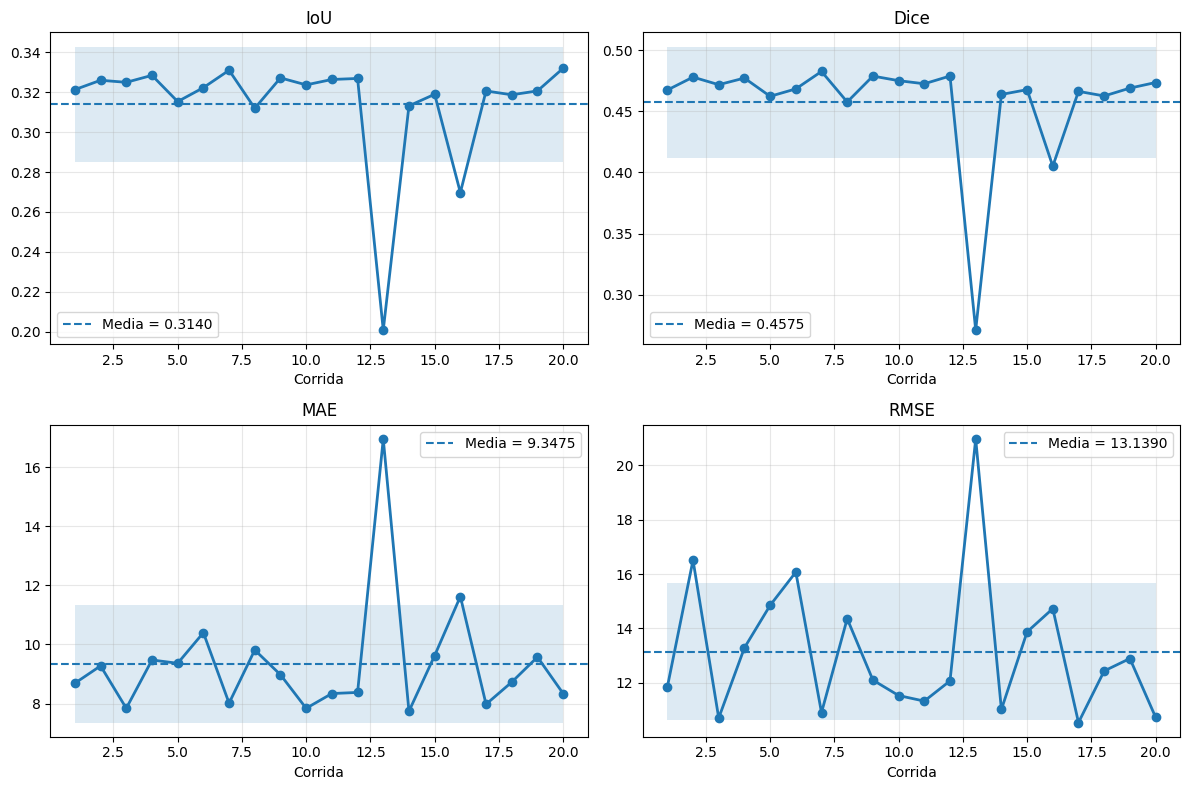

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

metrics = [
    ('iou', 'IoU'),
    ('dice', 'Dice'),
    ('mae', 'MAE'),
    ('rmse', 'RMSE')
]

for ax, (key, title) in zip(axes.flat, metrics):

    arr = np.array(results[key])
    runs = np.arange(1, len(arr)+1)

    ax.plot(
        runs,
        arr,
        marker='o',
        linewidth=2
    )

    ax.axhline(
        arr.mean(),
        linestyle='--',
        linewidth=1.5,
        label=f'Media = {arr.mean():.4f}'
    )

    ax.fill_between(
        runs,
        arr.mean()-arr.std(),
        arr.mean()+arr.std(),
        alpha=0.15
    )

    ax.set_title(title)
    ax.set_xlabel('Corrida')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig("results/metrics_per_run.png", dpi=300)
plt.show()

## 9. Visualización de Máscaras Predichas

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


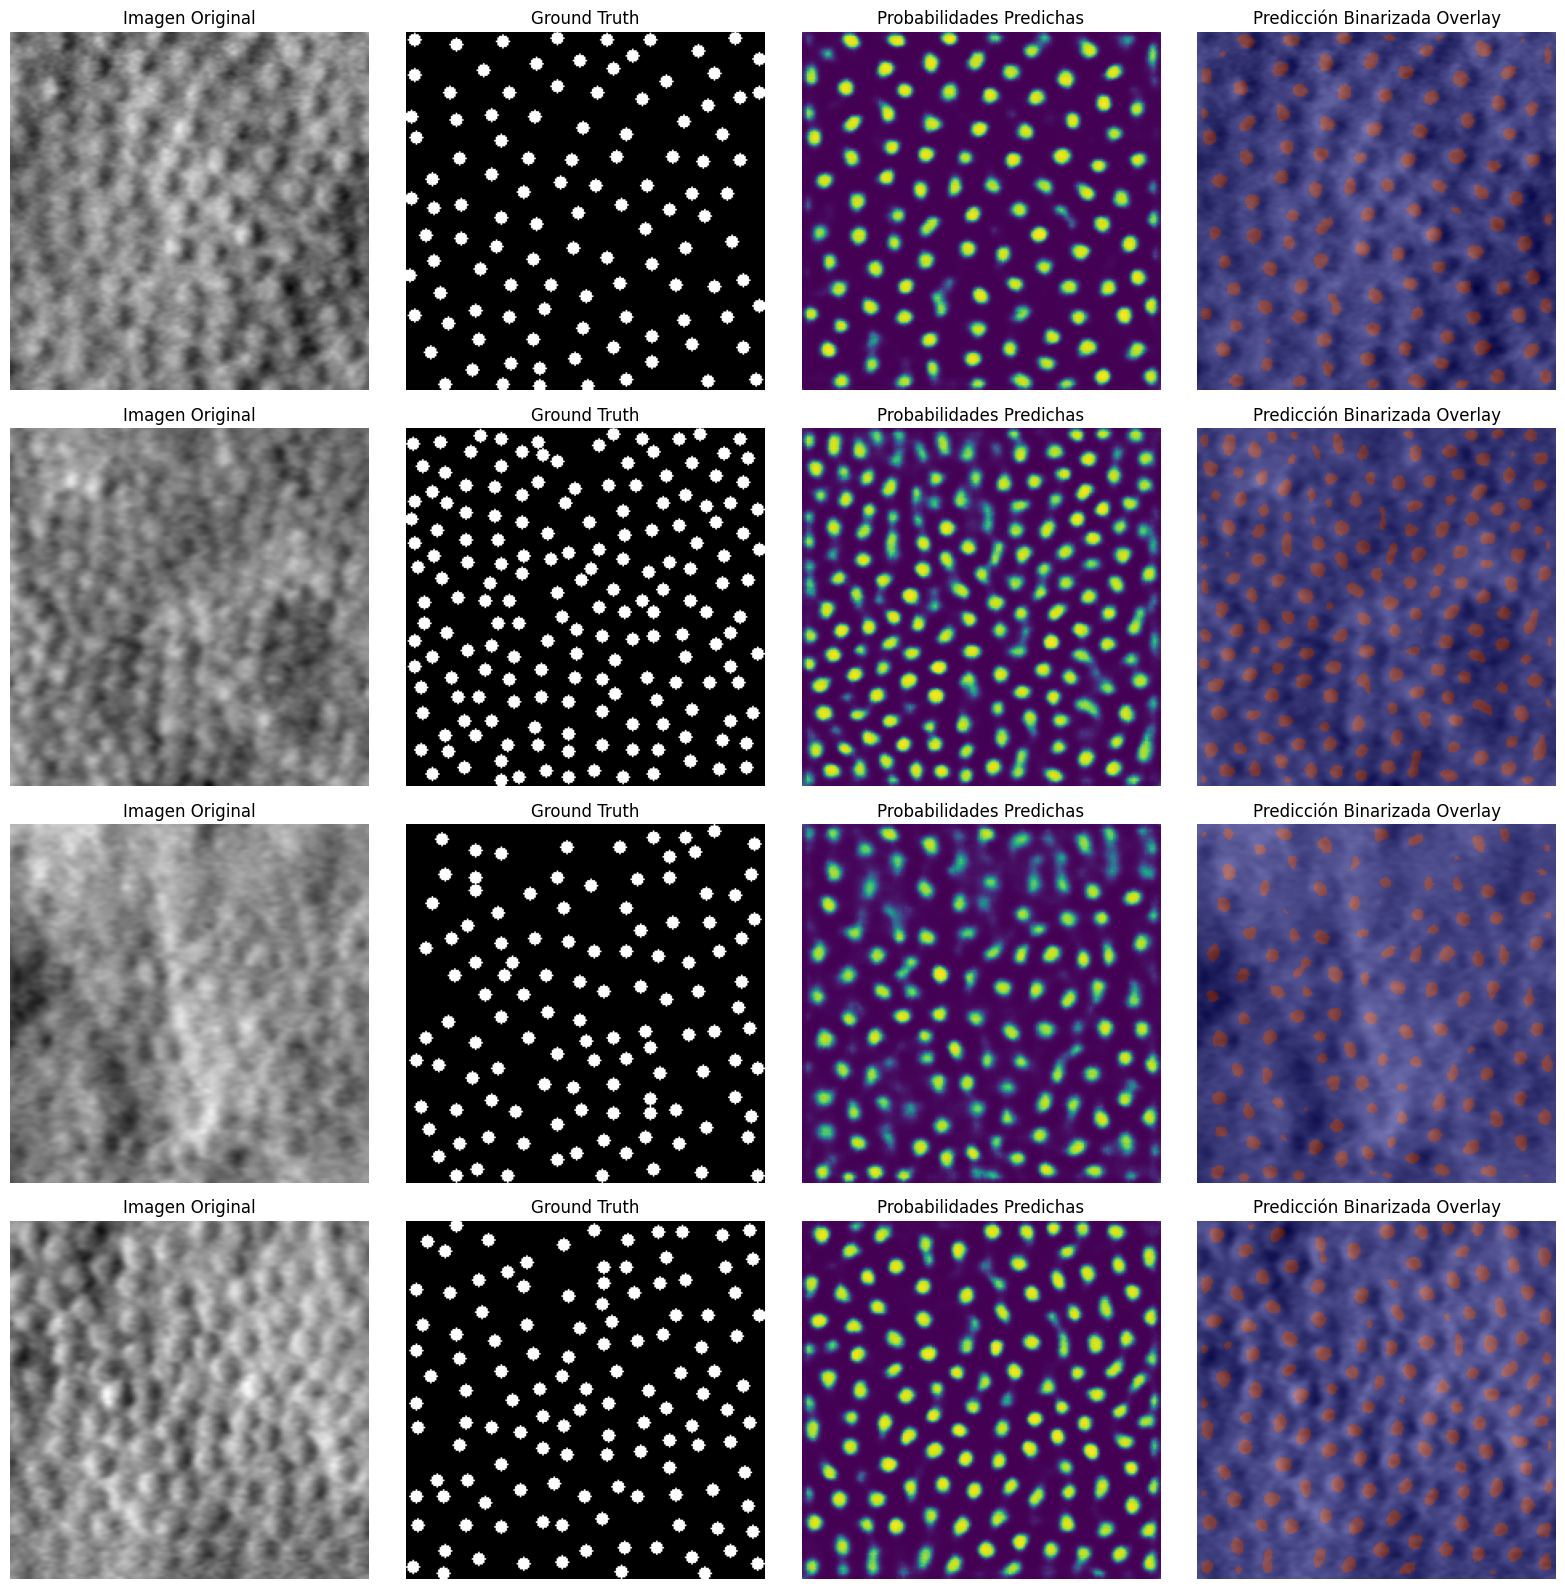

In [54]:
def visualize_predictions(X, y_true, num_samples=3):
    preds = model_run.predict(X[:num_samples*2]) # predecir un batch
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
    
    for i in range(num_samples):
        # Escoger un indice aleatorio entre los procesados
        idx = np.random.randint(0, num_samples*2)
        
        orig_img = X[idx]
        true_mask = y_true[idx].squeeze()
        pred_prob = preds[idx].squeeze()
        pred_mask = (pred_prob > 0.5).astype(np.float32)
        
        axes[i, 0].imshow(orig_img)
        axes[i, 0].set_title("Imagen Original")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(true_mask, cmap='gray')
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(pred_prob, cmap='viridis')
        axes[i, 2].set_title("Probabilidades Predichas")
        axes[i, 2].axis('off')
        
        axes[i, 3].imshow(orig_img)
        axes[i, 3].imshow(pred_mask, cmap='jet', alpha=0.5)
        axes[i, 3].set_title("Predicción Binarizada Overlay")
        axes[i, 3].axis('off')
        
    plt.tight_layout()
    plt.show()

visualize_predictions(X_val, y_val_masks, num_samples=4)

## 10. Conteo Final a partir de Máscaras Predichas

Para obtener un conteo a partir de la máscara de predicción, utilizamos un algoritmo de **Componentes Conectados**. Cada grupo de píxeles interconectados en la máscara binarizada se considerará como una célula individual.

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

Error Absoluto Medio (MAE) en el conteo final: 8.34 células
Root Mean Squared Error (RMSE) en el conteo final: 10.74 células


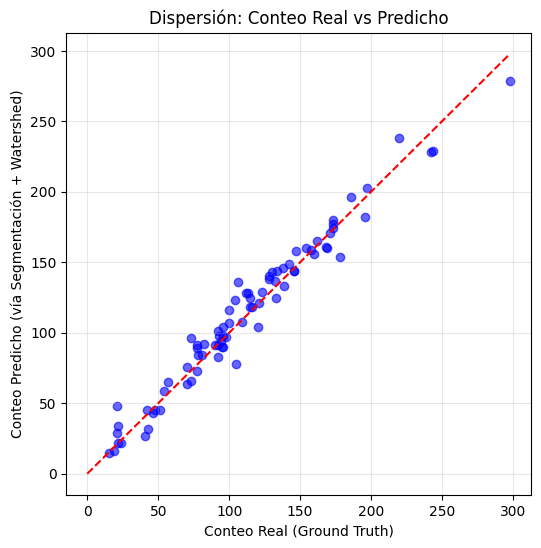

In [55]:
def count_cells_from_mask(mask_prob, threshold=0.5):
    # Binarizar la máscara
    binary_mask = (mask_prob > threshold).astype(np.uint8)
    
    # 1. Transformada de distancia (qué tan lejos está cada píxel blanco del fondo)
    distance = ndimage.distance_transform_edt(binary_mask)
    
    # 2. Encontrar picos locales (presumiblemente el centro de cada célula fusionada)
    local_max_coords = peak_local_max(distance, min_distance=3, labels=binary_mask)
    
    # 3. Crear marcadores únicos para cada pico detectado
    markers = np.zeros(distance.shape, dtype=bool)
    if len(local_max_coords) > 0:
        markers[tuple(local_max_coords.T)] = True
    markers, _ = label(markers, return_num=True)
    
    # 4. Aplicar algoritmo Watershed para separar las células basándose en la topografía de distancia
    labeled_mask = watershed(-distance, markers, mask=binary_mask)
    
    # Contar componentes únicos (excluyendo el fondo que es 0)
    num_features = len(np.unique(labeled_mask)) - 1 if 0 in labeled_mask else len(np.unique(labeled_mask))
    
    return num_features

# Evaluar en el conjunto de validación con Watershed
val_preds = model_run.predict(X_val, batch_size=8)
pred_counts = []

for p in val_preds:
    cnt = count_cells_from_mask(p.squeeze(), threshold=0.5)
    pred_counts.append(cnt)

pred_counts = np.array(pred_counts)

# Calcular métricas de error en el conteo
mae_count = np.mean(np.abs(val_counts - pred_counts))
rmse_count = np.sqrt(np.mean(np.square(val_counts - pred_counts)))

print(f"\nError Absoluto Medio (MAE) en el conteo final: {mae_count:.2f} células")
print(f"Root Mean Squared Error (RMSE) en el conteo final: {rmse_count:.2f} células")

# Gráfico de dispersión (Predicción vs Real)
plt.figure(figsize=(6, 6))
plt.scatter(val_counts, pred_counts, alpha=0.6, color='b')
plt.plot([0, max(val_counts)], [0, max(val_counts)], 'r--') # Línea ideal
plt.xlabel("Conteo Real (Ground Truth)")
plt.ylabel("Conteo Predicho (vía Segmentación + Watershed)")
plt.title("Dispersión: Conteo Real vs Predicho")
plt.grid(True, alpha=0.3)
plt.show()


## 11. Resultados

Con el objetivo de evaluar la estabilidad y reproducibilidad del modelo propuesto, se realizaron **20 ejecuciones independientes** del Vision Transformer ligero utilizando diferentes semillas aleatorias. En cada corrida se registraron métricas de segmentación (IoU y Dice), métricas de conteo celular (MAE y RMSE), número de épocas efectivamente entrenadas y pérdida de validación.

### Resultados Cuantitativos

Los resultados obtenidos muestran un comportamiento generalmente estable entre ejecuciones. La mayoría de las corridas alcanzaron valores de IoU cercanos a 0.32 y valores de Dice alrededor de 0.46.

| Métrica           | Media | Desv. Est. | Mínimo | Máximo |
| ----------------- | ----- | ---------- | ------ | ------ |
| IoU               | 0.314 | 0.029      | 0.201  | 0.332  |
| Dice              | 0.457 | 0.045      | 0.271  | 0.483  |
| MAE               | 9.35  | 1.99       | 7.74   | 16.96  |
| RMSE              | 13.14 | 2.52       | 10.54  | 20.97  |
| Épocas Entrenadas | 90.35 | 9.41       | 70     | 100    |
| Validation Loss   | 0.863 | 0.044      | 0.835  | 1.033  |

Los resultados indican que el modelo logra una segmentación consistente entre distintas inicializaciones aleatorias. La variabilidad observada en las métricas de segmentación es relativamente baja considerando la complejidad de la tarea y el tamaño reducido del modelo.

### Desempeño en Segmentación

El mejor desempeño obtenido durante los experimentos correspondió a:

* **IoU máximo:** 0.3321
* **Dice máximo:** 0.4826

Mientras que los valores mínimos observados fueron:

* **IoU mínimo:** 0.2008
* **Dice mínimo:** 0.2712

La diferencia entre los mejores y peores resultados evidencia que la inicialización aleatoria tiene cierto impacto sobre el entrenamiento, aunque la mayoría de las ejecuciones se concentran alrededor de valores similares.

### Desempeño en Conteo Celular

Respecto al conteo de células, el modelo obtuvo:

* **MAE promedio:** 9.35 células.
* **RMSE promedio:** 13.14 células.

Considerando que las imágenes contienen decenas o incluso cientos de células, estos errores indican que el procedimiento de segmentación seguido del postprocesamiento mediante watershed logra estimaciones razonablemente cercanas al conteo real.

### Estabilidad Experimental

La mayoría de las corridas finalizaron entre 80 y 100 épocas, lo que sugiere que el criterio de Early Stopping permitió una convergencia relativamente consistente. Asimismo, la baja dispersión observada en las métricas principales indica que la arquitectura presenta un comportamiento estable frente a cambios en la semilla de inicialización.


## 12. Discusión

Los resultados obtenidos demuestran que un Vision Transformer ligero puede aprender representaciones útiles para la segmentación celular incluso utilizando una arquitectura compacta de aproximadamente 802 mil parámetros.

Una de las principales fortalezas observadas es la consistencia del modelo. Exceptuando algunas ejecuciones con desempeño inferior, la mayoría de las corridas alcanzaron valores muy similares de IoU y Dice, lo que sugiere que el entrenamiento no depende excesivamente de una única inicialización favorable.

Sin embargo, también se identificaron algunas limitaciones. En particular, se observan dos ejecuciones con desempeños considerablemente inferiores al resto de experimentos. La corrida con IoU igual a 0.2008 y Dice igual a 0.2712 presentó además el mayor error de conteo (MAE = 16.96 células), lo que indica una convergencia hacia una solución subóptima. Este comportamiento puede atribuirse a la naturaleza estocástica del proceso de optimización y constituye evidencia de cierta sensibilidad a la inicialización aleatoria.

Otro aspecto relevante es que los valores de Dice obtenidos se mantienen en torno a 0.46–0.48. Aunque estos resultados evidencian capacidad de segmentación, también sugieren que existe margen significativo de mejora. Parte de esta limitación puede deberse a la estrategia utilizada para generar las máscaras binarias a partir de los mapas de densidad, ya que cualquier error en las etiquetas afecta directamente el proceso de aprendizaje.

En términos de conteo celular, el postprocesamiento basado en transformada de distancia y watershed permitió convertir las máscaras segmentadas en estimaciones numéricas razonables. No obstante, cuando varias células aparecen muy próximas entre sí, el modelo tiende a generar regiones conectadas que dificultan la correcta separación durante el conteo.

Finalmente, la realización de 20 corridas independientes permitió obtener una evaluación mucho más robusta que la que se obtendría mediante una única ejecución. Este protocolo experimental proporciona evidencia sobre la reproducibilidad del método y permite cuantificar explícitamente la variabilidad asociada al entrenamiento.

## 13. Conclusiones

En este proyecto se desarrolló un sistema de segmentación semántica basado en un Vision Transformer ligero para el conteo automático de células en imágenes AOSLO.

La arquitectura propuesta logró segmentar regiones celulares de manera consistente, alcanzando un IoU promedio de 0.314 y un Dice promedio de 0.457 a través de 20 ejecuciones independientes. Estos resultados demuestran que incluso modelos Transformer compactos pueden aprender representaciones relevantes para tareas de análisis biomédico.

El procedimiento de postprocesamiento basado en watershed permitió transformar las máscaras predichas en estimaciones cuantitativas del número de células, obteniendo un error absoluto medio de 9.35 células y un RMSE de 13.14 células.

La evaluación mediante múltiples corridas confirmó una estabilidad razonable del modelo, aunque también reveló cierta sensibilidad a la inicialización aleatoria. Este hallazgo resalta la importancia de reportar resultados agregados mediante media y desviación estándar en lugar de depender de una única ejecución.

Como trabajo futuro, sería interesante comparar esta arquitectura con modelos especializados de segmentación biomédica como U-Net, Attention U-Net y Swin Transformer, así como explorar estrategias más sofisticadas para la generación de etiquetas y la separación de células adyacentes durante la etapa de conteo.

